<a href="https://colab.research.google.com/github/RafaelPradoTorres/California_exploratory_analisys/blob/main/California.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [13]:
from sklearn.datasets import fetch_california_housing

california = fetch_california_housing()
df = pd.DataFrame(california.data, columns=california.feature_names)
df['PRICE'] = california.target
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PRICE
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


# Explorando a base de dados



In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   PRICE       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [15]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PRICE
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [19]:
from scipy.stats import trim_mean
trim_mean(df['PRICE'], 0.1)

np.float64(1.9277299539728683)

With a trim mean lower than the mean, we can see that houses with big prices are influencing in the analisys

# Estimates of variability

Text(0, 0.5, 'Population')

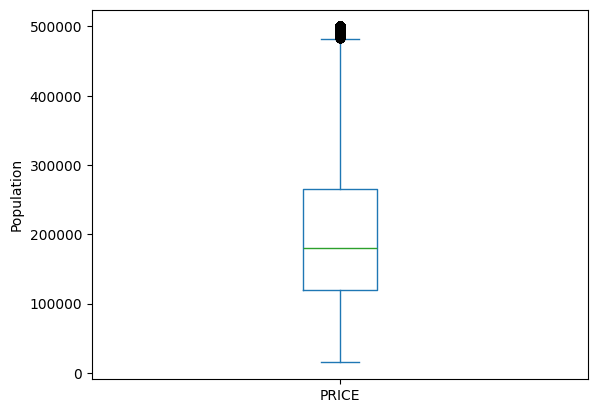

In [36]:
ax = (df['PRICE']*100_000).plot.box()
ax.set_ylabel('Population')

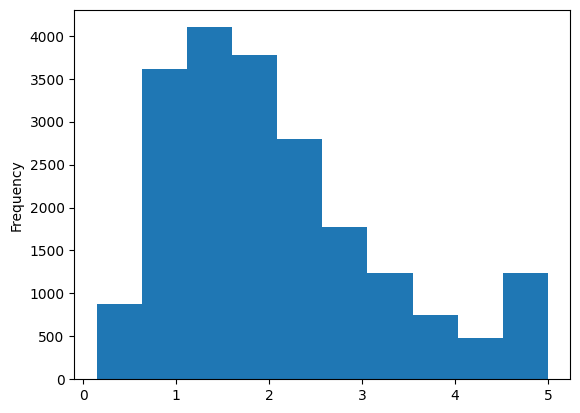

In [38]:
ax = df['PRICE'].plot.hist()

the histogram show us the mode is between 100000 and 150000 dollars

the concentration at the upper limit suggests the dataset caps values at $500,000.

In [117]:
df[df['PRICE'] == 5.00001].count()

,0
MedInc,965
HouseAge,965
AveRooms,965
AveBedrms,965
Population,965
AveOccup,965
Latitude,965
Longitude,965
PRICE,965


<Axes: >

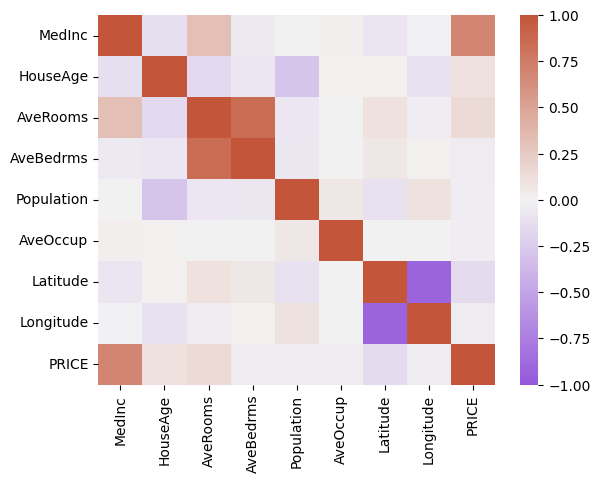

In [56]:
import seaborn as sns
sns.heatmap(df.corr(), vmin=-1, vmax=1,
            cmap=sns.diverging_palette(1000,20,as_cmap=True))

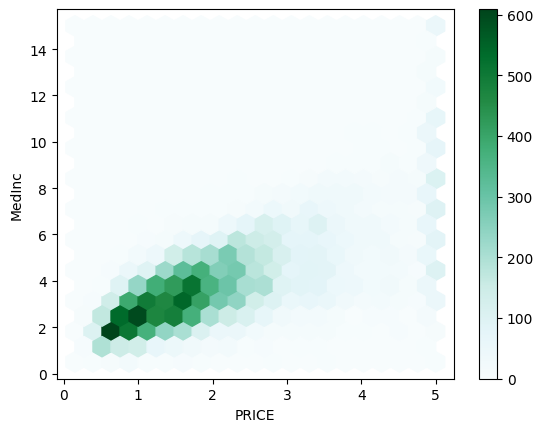

In [62]:
ax = df.plot.hexbin(x='PRICE', y='MedInc', gridsize=20)

we used kdeplot to see the correlation

[]

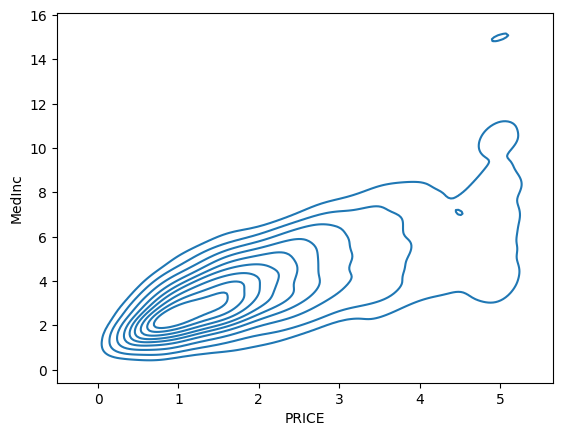

In [71]:
ax = sns.kdeplot(data=df, x="PRICE", y="MedInc")
ax.plot()

[]

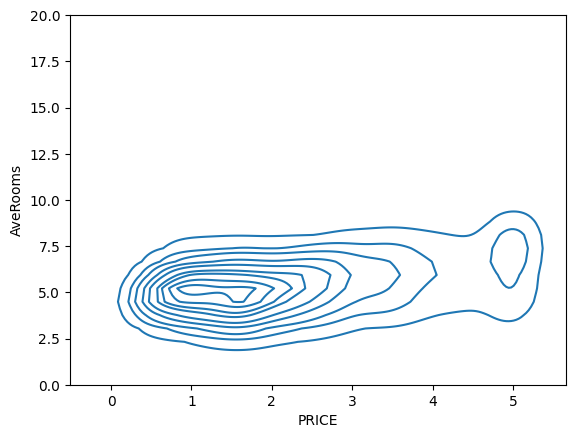

In [76]:
ax = sns.kdeplot(data=df, x="PRICE", y="AveRooms")
ax.set(ylim=(0,20))
ax.plot()

[]

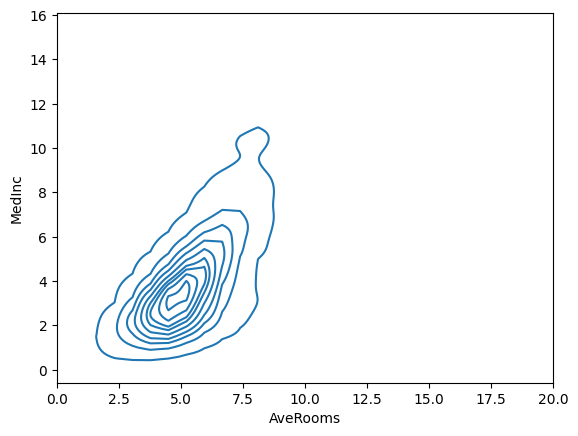

In [77]:
ax = sns.kdeplot(data=df, x="AveRooms", y="MedInc")
ax.set(xlim=(0,20))
ax.plot()

[]

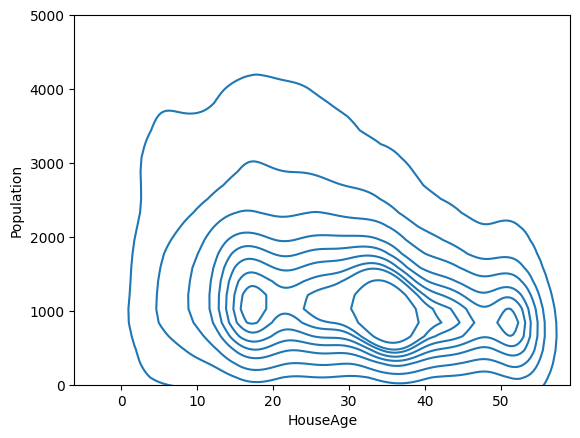

In [79]:
ax = sns.scatter(data=df, x="HouseAge", y="Population")
ax.set(ylim=(0,5000))
ax.plot()